In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("telco_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [9]:
df.drop('customerID', axis=1, inplace=True)

In [10]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

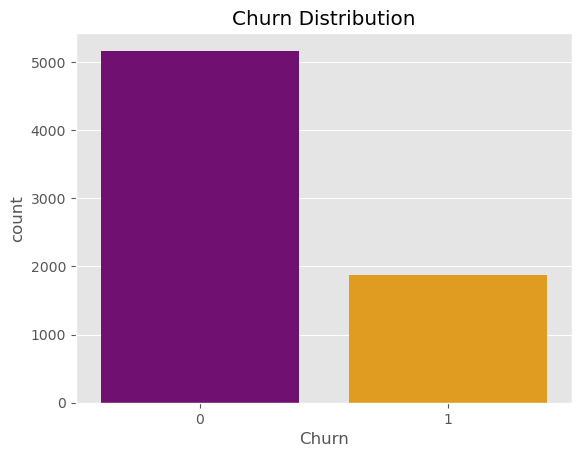

In [88]:
sns.countplot(
    x='Churn',
    hue='Churn',          # 🔥 add this
    data=df,
    palette=['purple', 'orange'],
    legend=False          # 🔥 remove duplicate legend
)

plt.title("Churn Distribution")
plt.show()

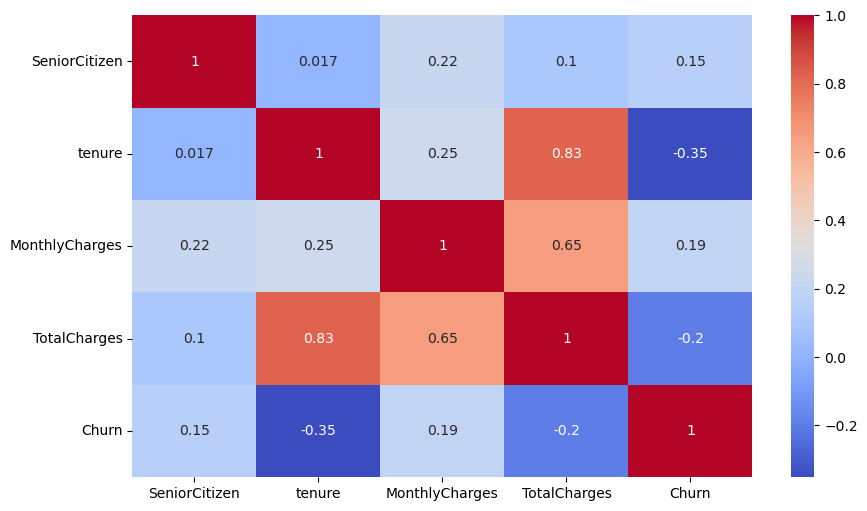

In [12]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

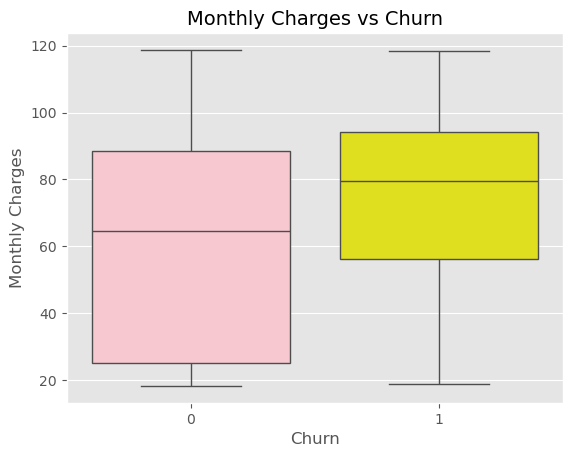

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('ggplot')  # optional for professional look

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    hue='Churn',                  # 🔥 add hue
    data=df,
    palette=['pink', 'yellow'],
    legend=False                  # remove extra legend
)

plt.title("Monthly Charges vs Churn", fontsize=14)
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [14]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [15]:
scaler = StandardScaler()

X = df.drop('Churn', axis=1)
y = df['Churn']

X_scaled = scaler.fit_transform(X)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [20]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [18]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [19]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.815471965933286
[[933 103]
 [157 216]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



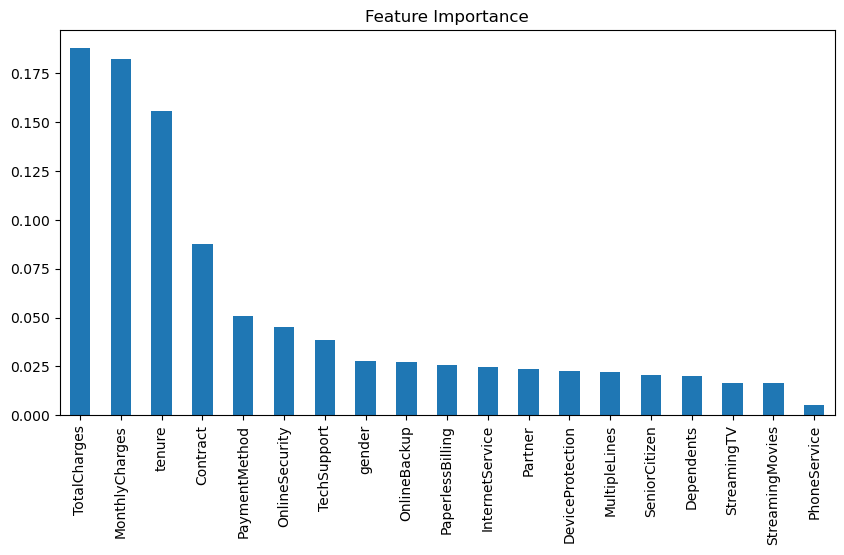

In [22]:
importances = rf.feature_importances_
features = X.columns

feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'n_estimators': 100}


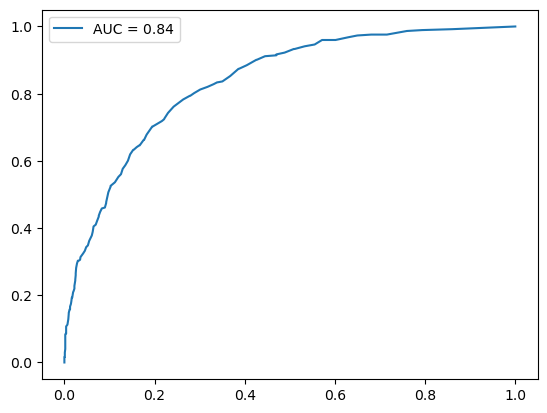

In [24]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.legend()
plt.show()

In [26]:
print(df.isnull().sum())

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [27]:
df = df.dropna()

In [28]:
X = df.drop(['Churn'], axis=1)

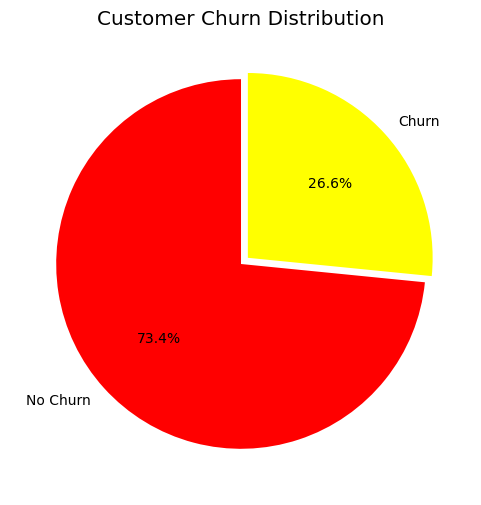

In [92]:
import matplotlib.pyplot as plt

churn_counts = df['Churn'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=['No Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['red', 'yellow'],  # 🔥 custom colors
    startangle=90,             # optional, rotate for better look
    explode=(0, 0.05)          # optional, slightly separate the 'Churn' slice
)
plt.title("Customer Churn Distribution")
plt.show()

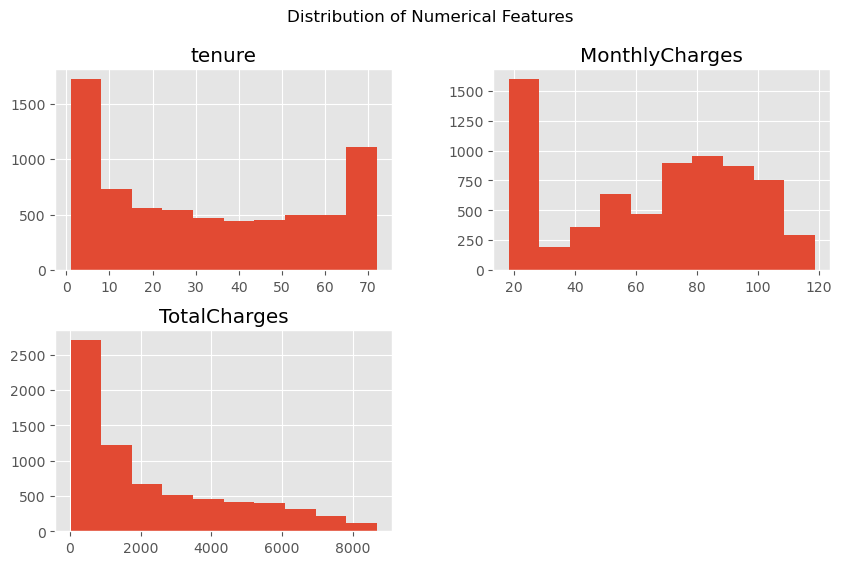

In [94]:
df[['tenure','MonthlyCharges','TotalCharges']].hist(figsize=(10,6))
plt.suptitle("Distribution of Numerical Features")
plt.show()

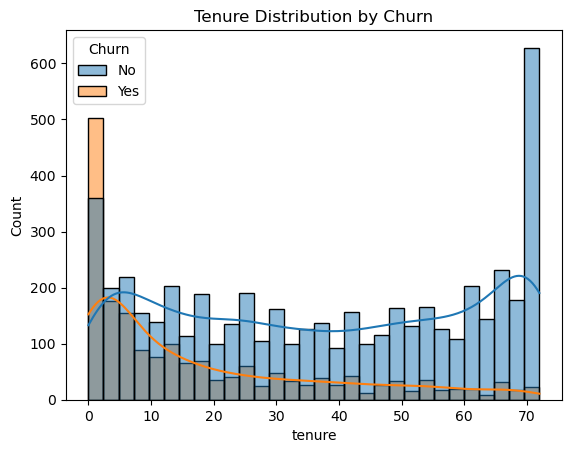

In [21]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()


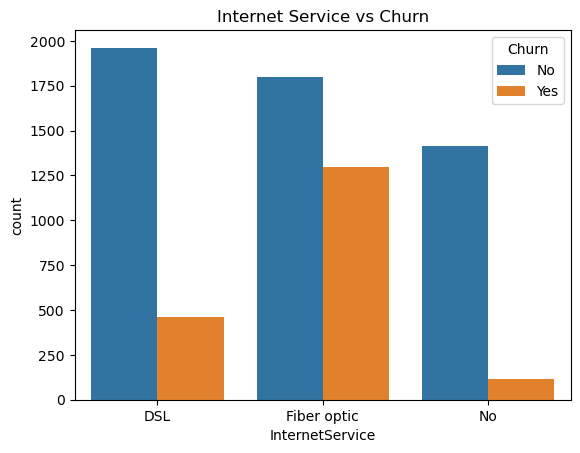

In [22]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Internet Service vs Churn")
plt.show()

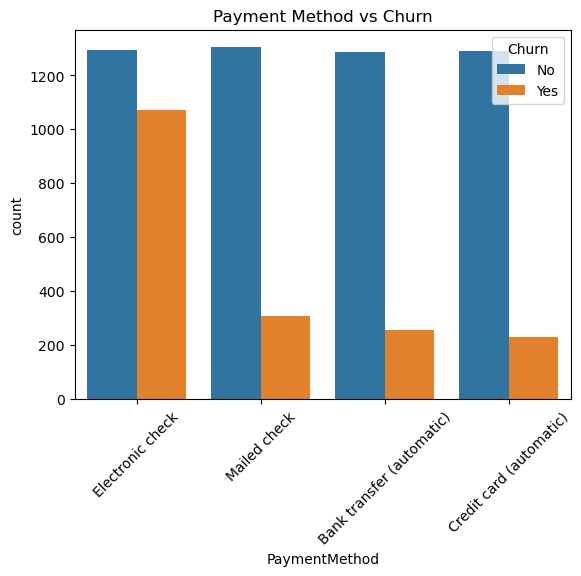

In [23]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

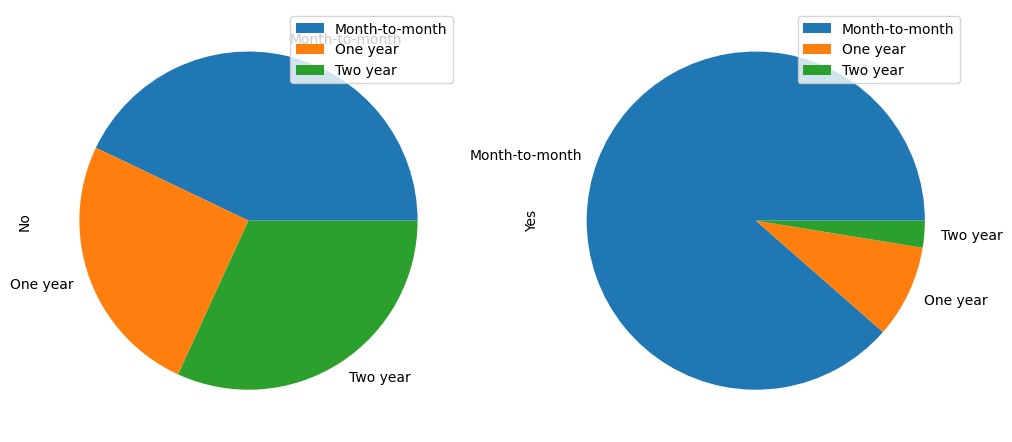

In [25]:
df.groupby('Contract')['Churn'].value_counts().unstack().plot(kind='pie', subplots=True, figsize=(12,6))
plt.show()

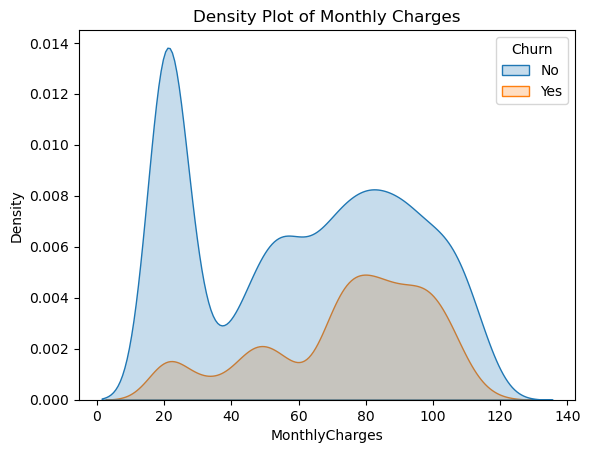

In [26]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title("Density Plot of Monthly Charges")
plt.show()

In [28]:
print(X_scaled.shape)
print(np.isnan(X_scaled).sum())
print(np.isinf(X_scaled).sum())

(7043, 19)
0
0


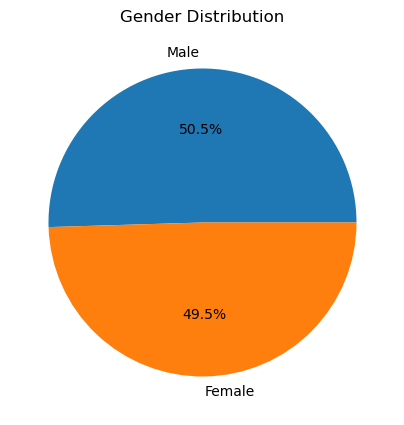

In [30]:
df['gender'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(5,5))
plt.title("Gender Distribution")
plt.ylabel('')
plt.show()

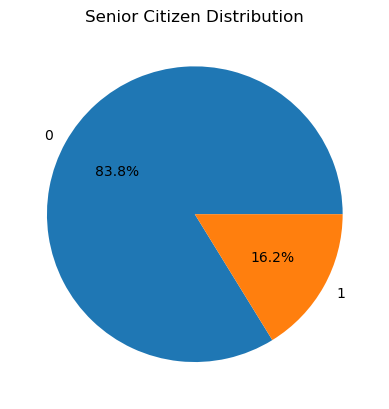

In [31]:
df['SeniorCitizen'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Senior Citizen Distribution")
plt.ylabel('')
plt.show()

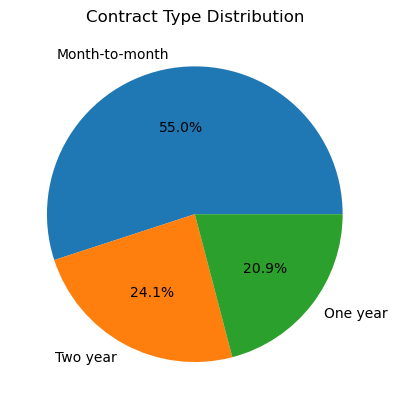

In [32]:
df['Contract'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Contract Type Distribution")
plt.ylabel('')
plt.show()

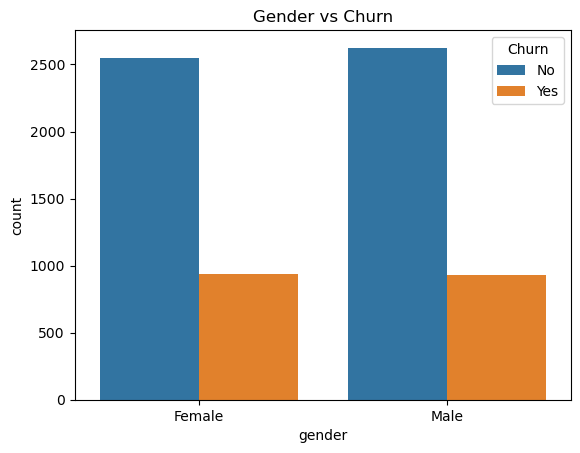

In [33]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title("Gender vs Churn")
plt.show()

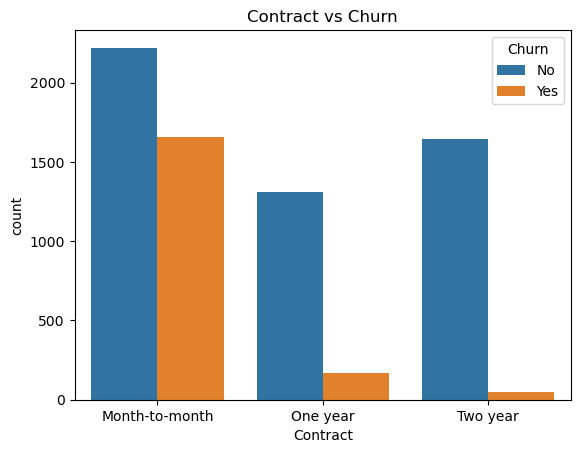

In [34]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Contract vs Churn")
plt.show()

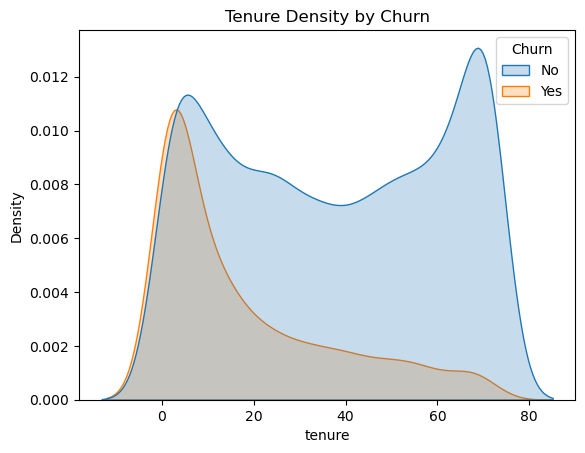

In [36]:
sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True)
plt.title("Tenure Density by Churn")
plt.show()

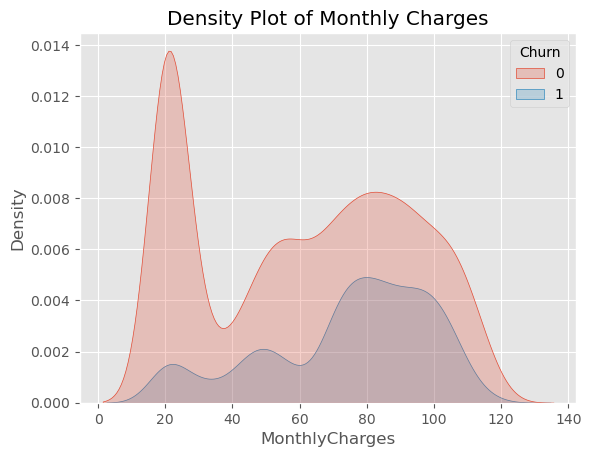

In [102]:
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', fill=True)
plt.title("Density Plot of Monthly Charges")
plt.show()

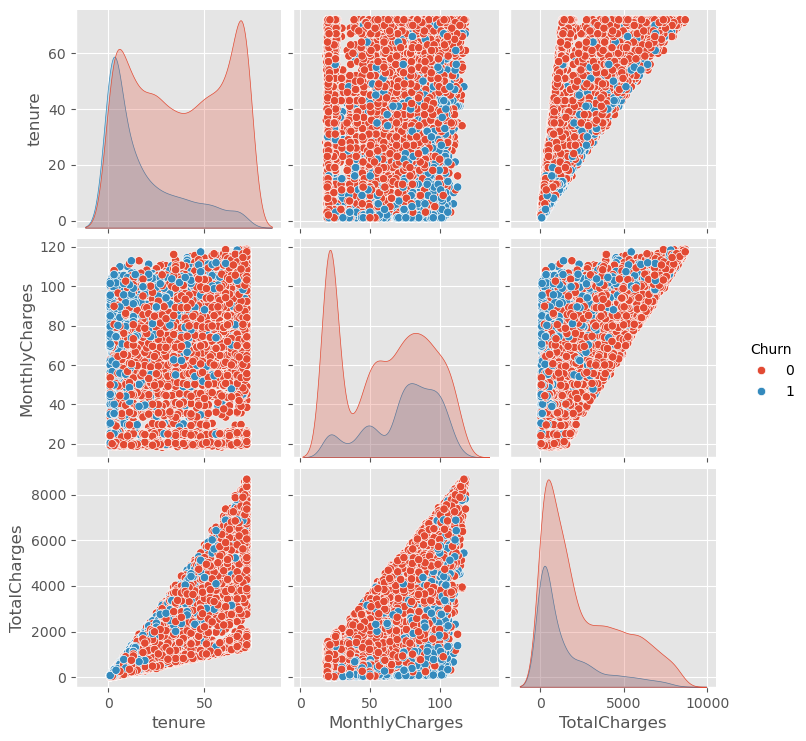

In [99]:
sns.pairplot(df[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')
plt.show()

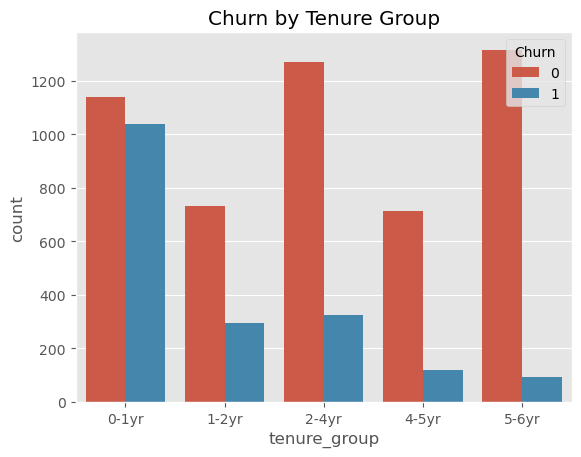

In [100]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0,12,24,48,60,72],
                           labels=['0-1yr','1-2yr','2-4yr','4-5yr','5-6yr'])

sns.countplot(x='tenure_group', hue='Churn', data=df)
plt.title("Churn by Tenure Group")
plt.show()

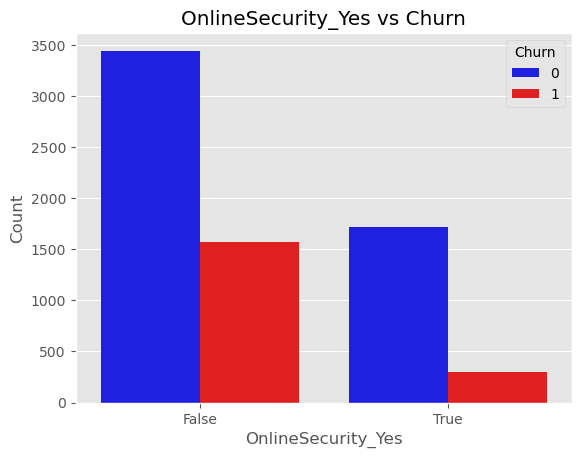

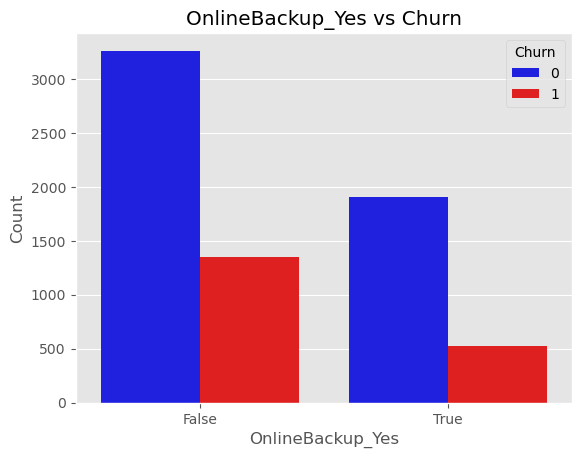

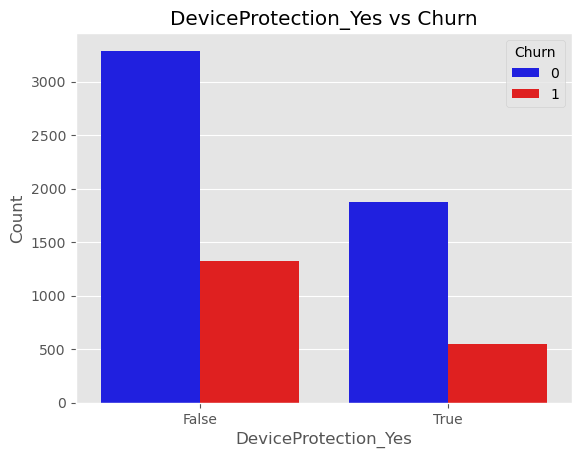

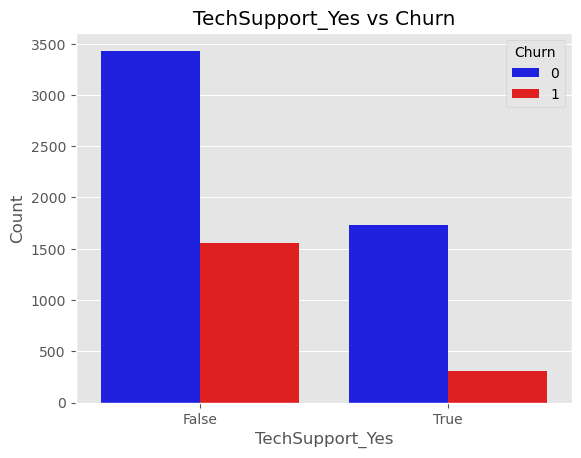

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

services = [
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes'
]

plt.style.use('ggplot')

for col in services:
    plt.figure()
    
    sns.countplot(
        x=df[col],        # 🔥 IMPORTANT CHANGE
        hue=df['Churn'],
        palette=['blue', 'red']
    )
    
    plt.title(f"{col} vs Churn")
    plt.xlabel(col)
    plt.ylabel("Count")
    
    plt.show()

In [54]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Results
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.7970191625266146
              precision    recall  f1-score   support

          No       0.83      0.91      0.87      1036
         Yes       0.66      0.48      0.55       373

    accuracy                           0.80      1409
   macro avg       0.75      0.69      0.71      1409
weighted avg       0.78      0.80      0.79      1409



In [62]:
import pandas as pd

# Remove customerID (not useful)
df = df.drop('customerID', axis=1)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Remove missing values
df = df.dropna()

In [63]:
# Convert target to 0/1
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

# Convert all categorical columns
df = pd.get_dummies(df, drop_first=True)

In [64]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

feature_names = X.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [65]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

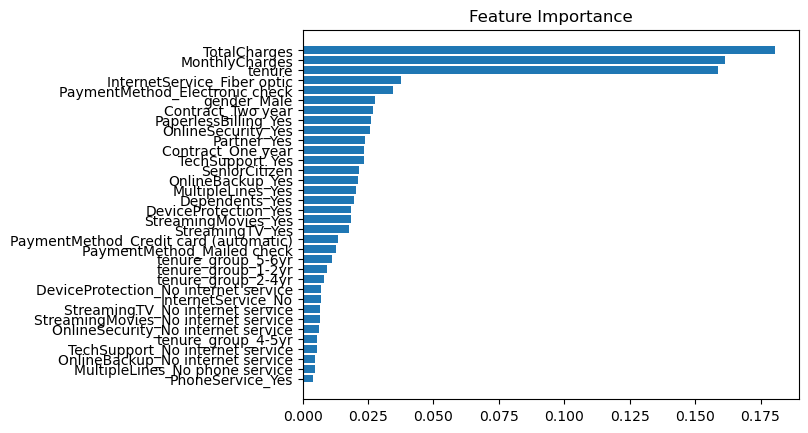

In [66]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(by='Importance')

plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importance")
plt.show()

In [67]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.6631130063965884
              precision    recall  f1-score   support

           0       0.91      0.60      0.72      1033
           1       0.43      0.84      0.57       374

    accuracy                           0.66      1407
   macro avg       0.67      0.72      0.65      1407
weighted avg       0.78      0.66      0.68      1407



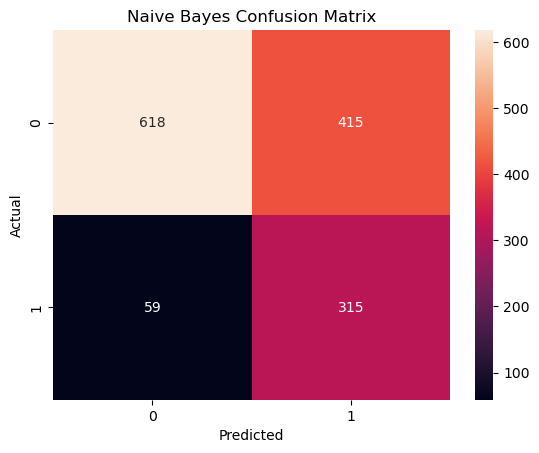

In [68]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_nb)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [72]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7142857142857143


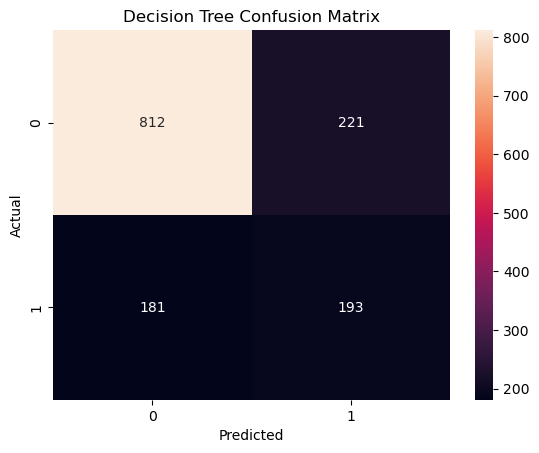

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure()
sns.heatmap(cm_dt, annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict ✅ (THIS WAS MISSING)
y_pred_rf = rf.predict(X_test)

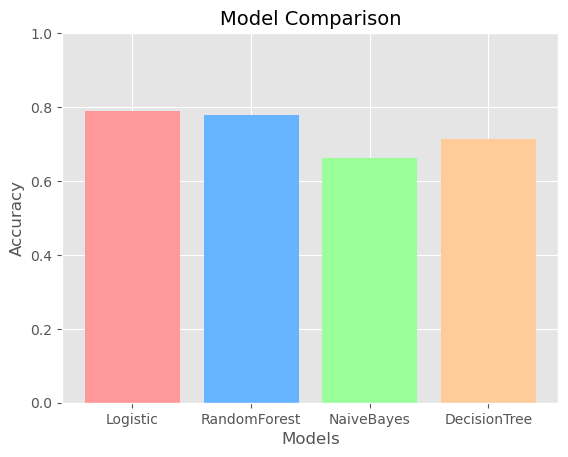

In [78]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

models = ['Logistic', 'RandomForest', 'NaiveBayes', 'DecisionTree']

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_nb),
    accuracy_score(y_test, y_pred_dt)
]

# 🔥 Apply style
plt.style.use('ggplot')

plt.figure()

# 🎨 Add colors
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

plt.bar(models, accuracy, color=colors)

# ✨ Extra styling (makes it look professional)
plt.title("Model Comparison", fontsize=14)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

In [84]:
print(df.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'tenure_group_1-2yr', 'tenure_group_2-4yr', 'tenure_group_4-5yr', 'tenure_group_5-6yr']
